# Lotka-Volterra Predator-Prey Model

**Methods:** Euler and RK4 integration, time-series and phase-space analysis; NumPy, Matplotlib

### Overview
This notebook explores the Lotka-Volterra predator-prey system using Euler's method and 4th Order Runge-Kutta method.

---

### Details:

Lotka-Volterra predator-prey system model equation:

$$
dx/dt = rx - axy
$$

$$
dy/dt = bxy - cy
$$

The initial conditions and internal parameters are given as follows: 

r = 1, a = 0.03, b = 0.024, c = 1, x_0 = 0.1, y_0 = 0.1

---

#### Importing necessary modules and defining shared parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
r = 1
a = 0.03
b = 0.024
c = 1
x_0 = 0.1
y_0 = 0.1

#### Define the functions of Euler and Runge-Kutta Method

In [2]:
def dXdt(t, X, Y):
  return r*X - a*X*Y

def dYdt(t, X, Y):
  return b*X*Y - c*Y

def euler(t, x_in, y_in):
  X = np.zeros_like(t)
  X[0] = x_in
  Y = np.zeros_like(t)
  Y[0] = y_in
  for n in range(0,t.shape[0]-1):
    h = dt*dXdt(t[n], X[n], Y[n])
    k = dt*dYdt(t[n], X[n], Y[n])
    X[n+1] = X[n]+h
    Y[n+1] = Y[n]+k
  return t, X, Y

def rk(t, x_in, y_in):
  X = np.zeros_like(t)
  X[0] = x_in
  Y = np.zeros_like(t)
  Y[0] = y_in
  for n in range(0,t.shape[0]-1):
    h1 = dt*dXdt(t[n], X[n], Y[n])
    k1 = dt*dYdt(t[n], X[n], Y[n])
    h2 = dt*dXdt(t[n]+dt/2.0, X[n]+h1/2.0, Y[n]+k1/2.0)
    k2 = dt*dYdt(t[n]+dt/2.0, X[n]+h1/2.0, Y[n]+k1/2.0)
    h3 = dt*dXdt(t[n]+dt/2.0, X[n]+h2/2.0, Y[n]+k2/2.0)
    k3 = dt*dYdt(t[n]+dt/2.0, X[n]+h2/2.0, Y[n]+k2/2.0)
    h4 = dt*dXdt(t[n]+dt, X[n]+h3, Y[n]+k3)
    k4 = dt*dYdt(t[n]+dt, X[n]+h3, Y[n]+k3)
    X[n+1] = X[n]+(h1+2*h2+2*h3+h4)/6
    Y[n+1] = Y[n]+(k1+2*k2+2*k3+k4)/6
  return t, X, Y

#### Solution for numerical methods

##### Set range for `dt` and solutions for each functions

In [3]:
dt = 0.001
t = np.arange(0.0,1000.0+dt,dt)
t, Xeuler, Yeuler = euler(t, x_0, y_0)
t, Xrk, Yrk = rk(t, x_0, y_0)

##### Visualizing the time-series of `X` and `Y`

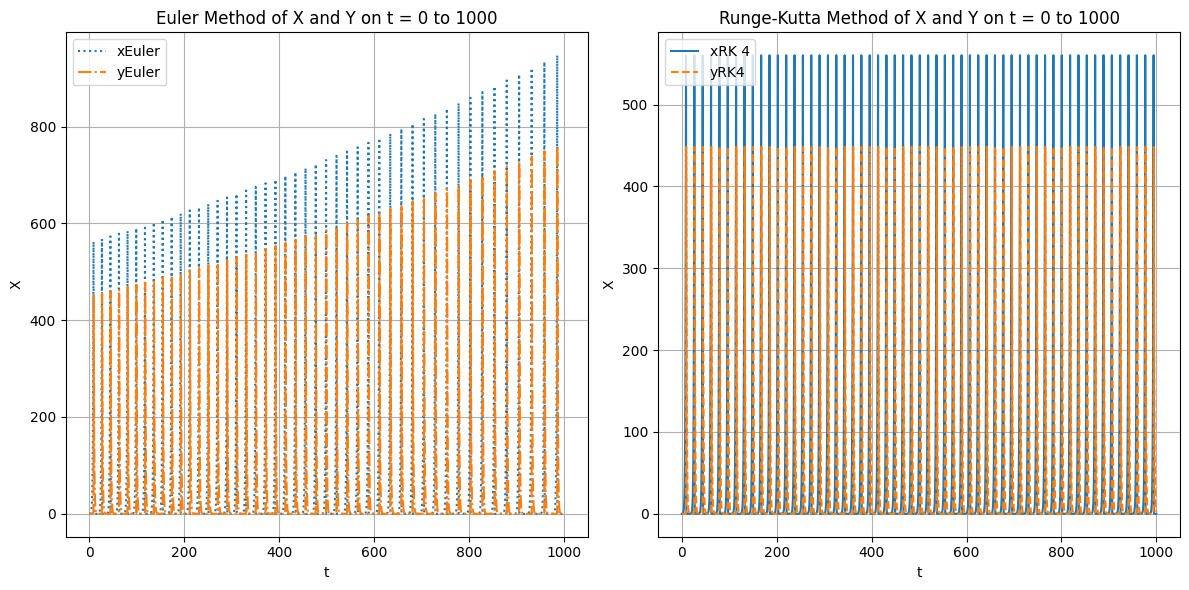

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].title.set_text('Euler Method of X and Y on t = 0 to 1000')
ax[0].plot(t, Xeuler, linestyle=':', label = "xEuler")
ax[0].plot(t, Yeuler, linestyle='-.', label = "yEuler")
ax[0].set_xlabel('t')
ax[0].set_ylabel('X')
ax[0].legend()
ax[0].grid(True)
ax[1].title.set_text('Runge-Kutta Method of X and Y on t = 0 to 1000')
ax[1].plot(t, Xrk, linestyle='-', label = "xRK 4")
ax[1].plot(t, Yrk, linestyle='--', label = "yRK4")
ax[1].set_xlabel('t')
ax[1].set_ylabel('X')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()

Comparing the two methods more closely

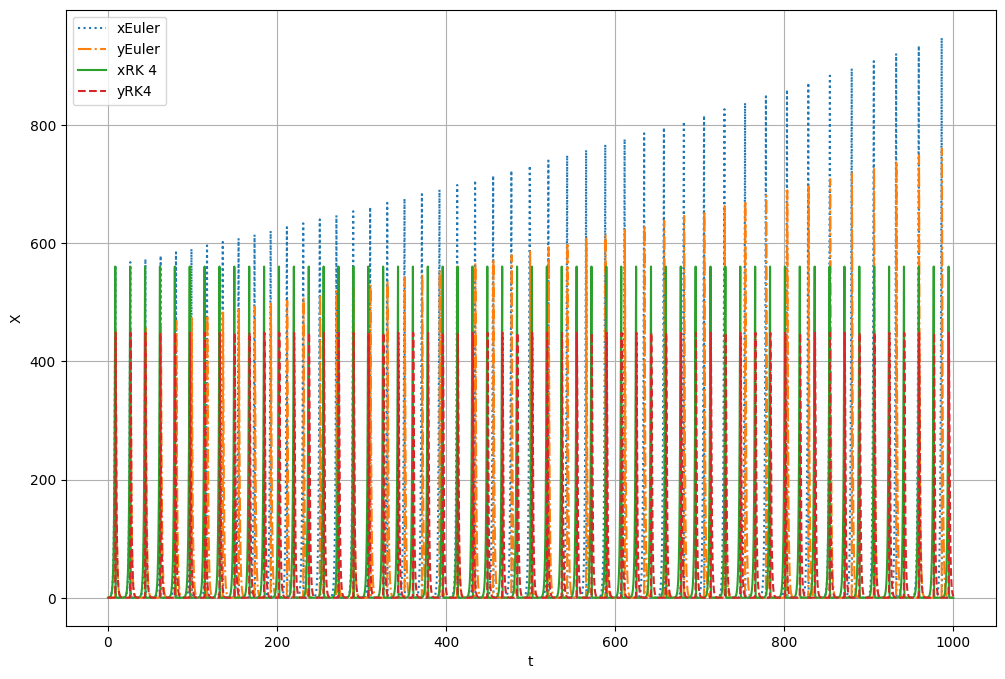

In [5]:
fig = plt.figure(figsize=(12,8))
plt.plot(t, Xeuler, linestyle=':', label = "xEuler")
plt.plot(t, Yeuler, linestyle='-.', label = "yEuler")
plt.plot(t, Xrk, linestyle='-', label = "xRK 4")
plt.plot(t, Yrk, linestyle='--', label = "yRK4")
plt.xlabel('t')
plt.ylabel('X')
plt.legend()
plt.grid(True)

Focusing at `t = 0` to `t = 200`

(0.0, 200.0)

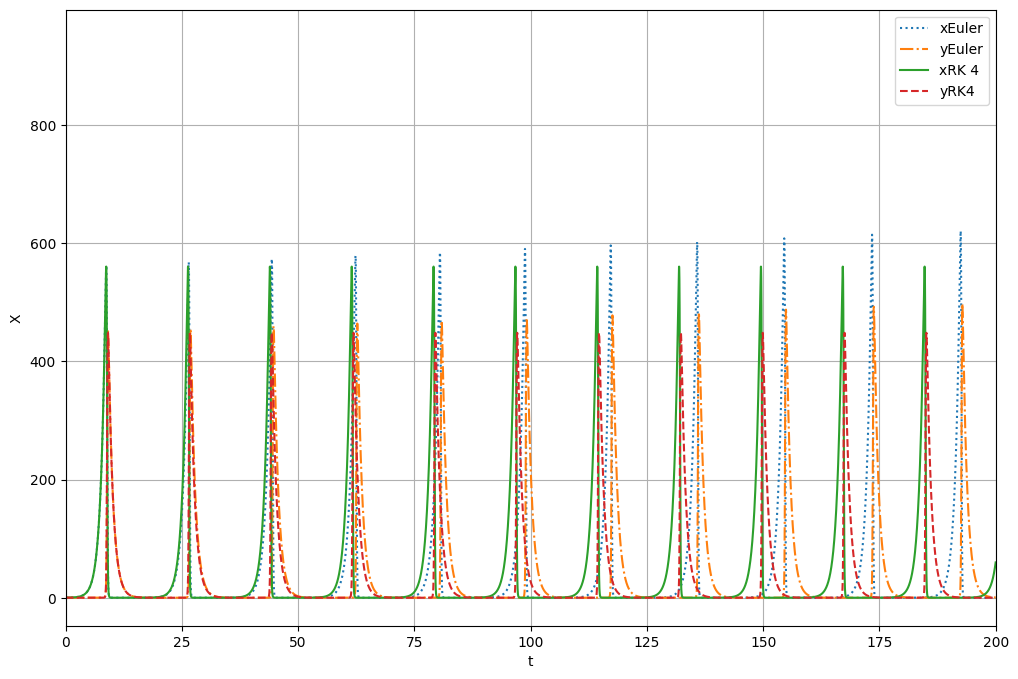

In [6]:
fig = plt.figure(figsize=(12,8))
plt.plot(t, Xeuler, linestyle=':', label = "xEuler")
plt.plot(t, Yeuler, linestyle='-.', label = "yEuler")
plt.plot(t, Xrk, linestyle='-', label = "xRK 4")
plt.plot(t, Yrk, linestyle='--', label = "yRK4")
plt.xlabel('t')
plt.ylabel('X')
plt.legend()
plt.grid(True)
plt.xlim(0,200)

##### Visualizing phase space between `X` and `Y`

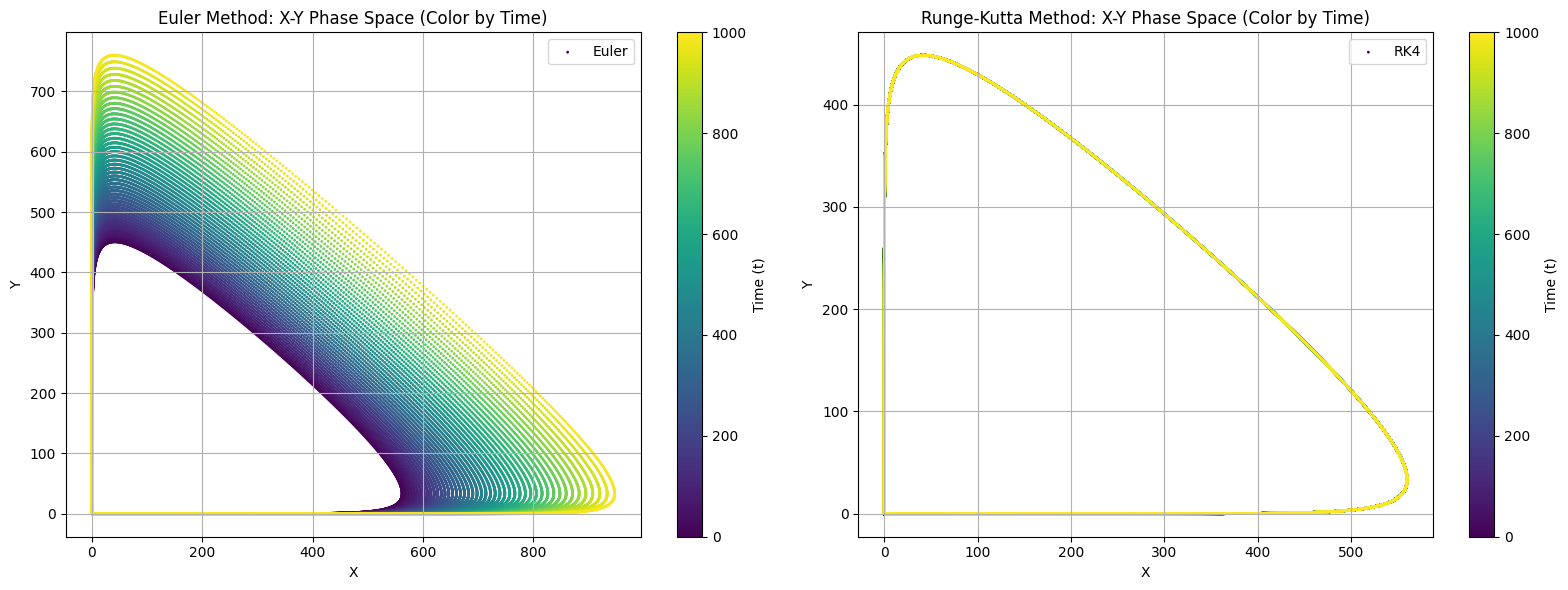

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))

plot_euler = ax[0].scatter(Xeuler, Yeuler, c=t, cmap='viridis', s=1, label = "Euler")
ax[0].title.set_text('Euler Method: X-Y Phase Space (Color by Time)')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].legend()
ax[0].grid(True)
plt.colorbar(plot_euler, ax=ax[0], label='Time (t)')

plot_rk = ax[1].scatter(Xrk, Yrk, c=t, cmap='viridis', s=1, label = "RK4")
ax[1].title.set_text('Runge-Kutta Method: X-Y Phase Space (Color by Time)')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].legend()
ax[1].grid(True)
plt.colorbar(plot_rk, ax=ax[1], label='Time (t)')

plt.tight_layout()

---

### Discussion

Over long integration times, RK4 conserves the system's closed orbit, while Euler's error injects numerical energy so the prey-predator cycle grows in amplitude over time.